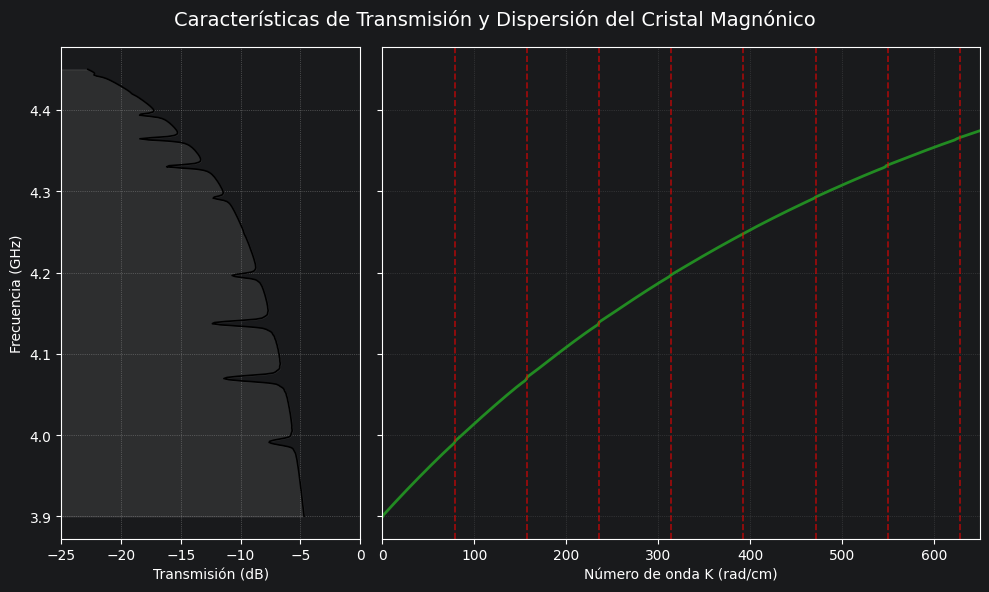

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. PARÁMETROS DEL SISTEMA
# =================================================================
gamma = 2.8
H0 = 770.0
Ms = 1750.0
deltaH = 0.5

wH = 2 * np.pi * (gamma * H0 / 1000.0)
wM = 2 * np.pi * (gamma * Ms / 1000.0)

dPF = 8.3
delta = 1.0
dG = dPF - delta
LPF = 330.0
LG = 70.0
Lambda = LPF + LG
Nperiods = 12

# =================================================================
# 2. FUNCIONES DE DISPERSIÓN, MATRICES Y TRANSMISIÓN
# =================================================================
def k_wave(w, d):
    arg = 1 + (4 / wM**2) * (wH * (wH + wM) - w**2)
    return -(1 / (2 * d)) * np.log(arg)

def v_group(w, d):
    k = k_wave(w, d)
    return (wM**2 * d * np.exp(-2 * k * d)) / (4 * w)

def k_prime(w, d):
    vg = np.abs(v_group(w, d))
    gamma_rad_ns = 2 * np.pi * (gamma * deltaH / 1000.0)
    return gamma_rad_ns / vg

GammaRef = delta / (2 * dPF - delta)

def T_interface(nu):
    mat = np.array([[1.0, nu * GammaRef], [nu * GammaRef, 1.0]], dtype=complex)
    return (1.0 / (1.0 - nu * GammaRef)) * mat

def T_prop(w, d, L):
    k = k_wave(w, d)
    kp = k_prime(w, d)
    return np.array([[np.exp(-(1j * k - kp) * L), 0.0],
                     [0.0, np.exp((1j * k - kp) * L)]], dtype=complex)

def T_cell(w):
    return T_prop(w, dPF, LPF) @ T_interface(1) @ T_prop(w, dG, LG) @ T_interface(-1)

# =================================================================
# 3. EVALUACIÓN NUMÉRICA (Transmisión y Vector de Bloch)
# =================================================================

# Frecuencias a evaluar (ajustadas para ver bien el detalle)
f_array = np.linspace(3.9, 4.45, 400)

trans_db = np.zeros(len(f_array))
raw_phis = np.zeros(len(f_array))

for i, f in enumerate(f_array):
    w = 2 * np.pi * f
    tc = T_cell(w)

    # 1. Cálculo de Transmisión
    T_total = np.linalg.matrix_power(tc, Nperiods)
    T11 = T_total[0, 0]
    trans_db[i] = 10 * np.log10(1.0 / (np.abs(T11)**2))

    # 2. Cálculo de Fase (Dispersión cruda)
    tr = np.trace(tc)
    raw_phis[i] = np.real(np.arccos(tr / 2.0))

# Desdoblamiento de fase (Esquema de Zona Extendida)
K_extended_um = np.zeros(len(f_array))
K_extended_um[0] = raw_phis[0]
for i in range(1, len(f_array)):
    d_phi = np.abs(raw_phis[i] - raw_phis[i-1])
    K_extended_um[i] = K_extended_um[i-1] + d_phi

# Convertir a rad/cm
K_array = (K_extended_um / Lambda) * 10000.0

# Límites de la Zona de Brillouin
n_zonas = 8
bz_boundaries = [(n * np.pi / Lambda) * 10000.0 for n in range(1, n_zonas + 1)]

# =================================================================
# 4. CREACIÓN DE LA FIGURA COMPUESTA (Estilo Fig. 3 del artículo)
# =================================================================

# gridspec_kw permite que la gráfica de dispersión sea más ancha que la de transmisión
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 6),
                               gridspec_kw={'width_ratios': [1, 2]})

# --- PANEL IZQUIERDO: Transmisión (Fig 3b) ---
ax1.plot(trans_db, f_array, color='black', linewidth=1.2)
ax1.set_xlabel('Transmisión (dB)')
ax1.set_ylabel('Frecuencia (GHz)')
ax1.set_xlim(-25, 0)
ax1.grid(True, linestyle=':', alpha=0.6)

# sombreamos la zona de caída para darle mejor estética
ax1.fill_betweenx(f_array, trans_db, -75, color='gray', alpha=0.2)

# --- PANEL DERECHO: Dispersión (Fig 3c) ---
ax2.plot(K_array, f_array, color='forestgreen', linewidth=2)
ax2.set_xlabel('Número de onda K (rad/cm)')
ax2.set_xlim(0, 650)
ax2.grid(True, linestyle=':', alpha=0.3)

# Añadir fronteras de la zona de Brillouin
for bz in bz_boundaries:
    if bz <= 650:
        ax2.axvline(x=bz, color='red', linestyle='--', alpha=0.6, linewidth=1.2)

plt.suptitle('Características de Transmisión y Dispersión del Cristal Magnónico', fontsize=14)
plt.tight_layout()

# Quitar el espacio entre las dos gráficas para que se vean como un bloque
plt.subplots_adjust(wspace=0.05)
plt.show()